# Notebook 07 — Post-Distillation Quantization

This notebook completes the compression pipeline by applying INT8 quantization to the best distilled student from Notebook 06. The correct order is distill first, then quantize — quantizing the teacher before distillation degrades dark knowledge quality, while quantizing the student after distillation preserves accuracy while achieving significant size reduction.

**Pipeline:** Train Teacher → Distill (KD → DKD → FitNets+DKD → Pruned+DKD+FitNets) → Quantize Student

**Best distilled student (Notebook 06):** 70.78% at 0.28M params

## 1. Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os

DRIVE_BASE  = '/content/drive/MyDrive/kd_project'
CKPT_DIR    = f'{DRIVE_BASE}/checkpoints'
RESULTS_DIR = f'{DRIVE_BASE}/results'

# Best student checkpoint from Notebook 06
BEST_STUDENT_CKPT = f'{CKPT_DIR}/pruned_teacher_dkd_fitnet_student.pth'
assert os.path.exists(BEST_STUDENT_CKPT), \
    f'Student checkpoint not found. Run Notebook 06 first.'

print('Drive mounted.')
print(f'Best student checkpoint found: {BEST_STUDENT_CKPT}')

Mounted at /content/drive
Drive mounted.
Best student checkpoint found: /content/drive/MyDrive/kd_project/checkpoints/pruned_teacher_dkd_fitnet_student.pth


## 2. Install torchao and Setup

In [2]:
!pip install torchao -q

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from torchao.quantization import quantize_, int8_weight_only

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
print('torchao ready — GPU quantization available.')

Device : cuda
GPU    : NVIDIA RTX PRO 6000 Blackwell Server Edition
torchao ready — GPU quantization available.


## 3. Data Loading

In [4]:
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5071, 0.4867, 0.4408),
                         std=(0.2675, 0.2565, 0.2761))
])

test_dataset = torchvision.datasets.CIFAR100(root='./data', train=False,
                                              download=True, transform=test_transform)
test_loader  = torch.utils.data.DataLoader(test_dataset, batch_size=128,
                                            shuffle=False, num_workers=2, pin_memory=True)
print(f'Test samples : {len(test_dataset):,}')

100%|██████████| 169M/169M [00:06<00:00, 26.4MB/s]


Test samples : 10,000


## 4. Model Architecture

In [5]:
class BasicBlock(nn.Module):
    expansion = 1
    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1    = nn.Conv2d(in_channels, out_channels, 3, stride, 1, bias=False)
        self.bn1      = nn.BatchNorm2d(out_channels)
        self.relu     = nn.ReLU(inplace=True)
        self.conv2    = nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False)
        self.bn2      = nn.BatchNorm2d(out_channels)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
    def forward(self, x):
        out  = self.relu(self.bn1(self.conv1(x)))
        out  = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return self.relu(out)

class ResNet_CIFAR(nn.Module):
    def __init__(self, block, num_blocks, num_classes=100):
        super(ResNet_CIFAR, self).__init__()
        self.in_channels = 16
        self.conv1   = nn.Conv2d(3, 16, 3, 1, 1, bias=False)
        self.bn1     = nn.BatchNorm2d(16)
        self.relu    = nn.ReLU(inplace=True)
        self.layer1  = self._make_layer(block, 16, num_blocks[0], stride=1)
        self.layer2  = self._make_layer(block, 32, num_blocks[1], stride=2)
        self.layer3  = self._make_layer(block, 64, num_blocks[2], stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc      = nn.Linear(64 * block.expansion, num_classes)
        self._init_weights()
    def _make_layer(self, block, out_ch, num_blocks, stride):
        layers = []
        for s in [stride] + [1]*(num_blocks-1):
            layers.append(block(self.in_channels, out_ch, s))
            self.in_channels = out_ch
        return nn.Sequential(*layers)
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1); nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01); nn.init.constant_(m.bias, 0)
    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out); out = self.layer2(out); out = self.layer3(out)
        out = self.avgpool(out); out = torch.flatten(out, 1)
        return self.fc(out)

def ResNet20(num_classes=100): return ResNet_CIFAR(BasicBlock, [3,3,3], num_classes)

print('Architecture defined.')

Architecture defined.


## 5. Load Best Distilled Student and Evaluate

In [6]:
def evaluate(model, loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            correct += (model(images).argmax(dim=1) == labels).sum().item()
            total   += images.size(0)
    return 100.0 * correct / total

def model_size_mb(model):
    """Estimate model size in MB from parameter count."""
    total_params = sum(p.numel() for p in model.parameters())
    return total_params * 4 / (1024 ** 2)  # float32 = 4 bytes


# Load best student from Notebook 06
student = ResNet20(num_classes=100).to(device)
student.load_state_dict(torch.load(BEST_STUDENT_CKPT, map_location=device))

acc_before = evaluate(student, test_loader, device)
size_before = model_size_mb(student)
params = sum(p.numel() for p in student.parameters())

print(f'Student before quantization:')
print(f'  Accuracy   : {acc_before:.2f}%')
print(f'  Parameters : {params:,} ({params/1e6:.2f}M)')
print(f'  Model size : {size_before:.2f} MB (float32)')

Student before quantization:
  Accuracy   : 70.78%
  Parameters : 278,324 (0.28M)
  Model size : 1.06 MB (float32)


## 6. Apply INT8 Quantization to Student

torchao's `int8_weight_only` quantization runs on GPU and reduces weight precision from float32 to INT8 — a 4x reduction in weight storage with minimal accuracy impact.

In [7]:
# Apply INT8 weight-only quantization using torchao on GPU
quantize_(student, int8_weight_only())

acc_after = evaluate(student, test_loader, device)

print(f'Student after INT8 quantization:')
print(f'  Accuracy   : {acc_after:.2f}%')
print(f'  Accuracy drop : {acc_before - acc_after:.2f}%')
print(f'  Weight precision: float32 → INT8 (4x size reduction)')

Student after INT8 quantization:
  Accuracy   : 70.75%
  Accuracy drop : 0.03%
  Weight precision: float32 → INT8 (4x size reduction)


## 7. Complete Pipeline Results

In [8]:
TEACHER_ACC  = 72.95
BASELINE_ACC = 67.97
KD_ACC       = 69.02
DKD_ACC      = 70.43
FITNET_ACC   = 70.53
PRUNED_ACC   = 70.78

print('=' * 65)
print('  Complete Compression Pipeline — Final Results')
print('=' * 65)
print(f'  Teacher (ResNet-110)                    : {TEACHER_ACC:.2f}%  — 1.74M params')
print(f'  Student baseline (no KD)                : {BASELINE_ACC:.2f}%  — 0.28M params')
print(f'  Classical KD (T=4)                      : {KD_ACC:.2f}%  — 0.28M params')
print(f'  DKD                                     : {DKD_ACC:.2f}%  — 0.28M params')
print(f'  FitNets + DKD                           : {FITNET_ACC:.2f}%  — 0.28M params')
print(f'  Pruned Teacher + DKD + FitNets          : {PRUNED_ACC:.2f}%  — 0.28M params (float32)')
print(f'  + INT8 Quantization (this notebook)     : {acc_after:.2f}%  — 0.28M params (INT8)')
print(f'  Remaining gap to teacher                : {TEACHER_ACC - acc_after:.2f}%')
print('=' * 65)
print(f'\n  Quantization impact:')
print(f'  Accuracy drop  : {acc_before - acc_after:.2f}%')
print(f'  Weight size    : float32 → INT8 (4x reduction in weight storage)')
print(f'  Deployment benefit: significantly faster inference on edge devices')

  Complete Compression Pipeline — Final Results
  Teacher (ResNet-110)                    : 72.95%  — 1.74M params
  Student baseline (no KD)                : 67.97%  — 0.28M params
  Classical KD (T=4)                      : 69.02%  — 0.28M params
  DKD                                     : 70.43%  — 0.28M params
  FitNets + DKD                           : 70.53%  — 0.28M params
  Pruned Teacher + DKD + FitNets          : 70.78%  — 0.28M params (float32)
  + INT8 Quantization (this notebook)     : 70.75%  — 0.28M params (INT8)
  Remaining gap to teacher                : 2.20%

  Quantization impact:
  Accuracy drop  : 0.03%
  Weight size    : float32 → INT8 (4x reduction in weight storage)
  Deployment benefit: significantly faster inference on edge devices


## 8. Compression Pipeline Visualization

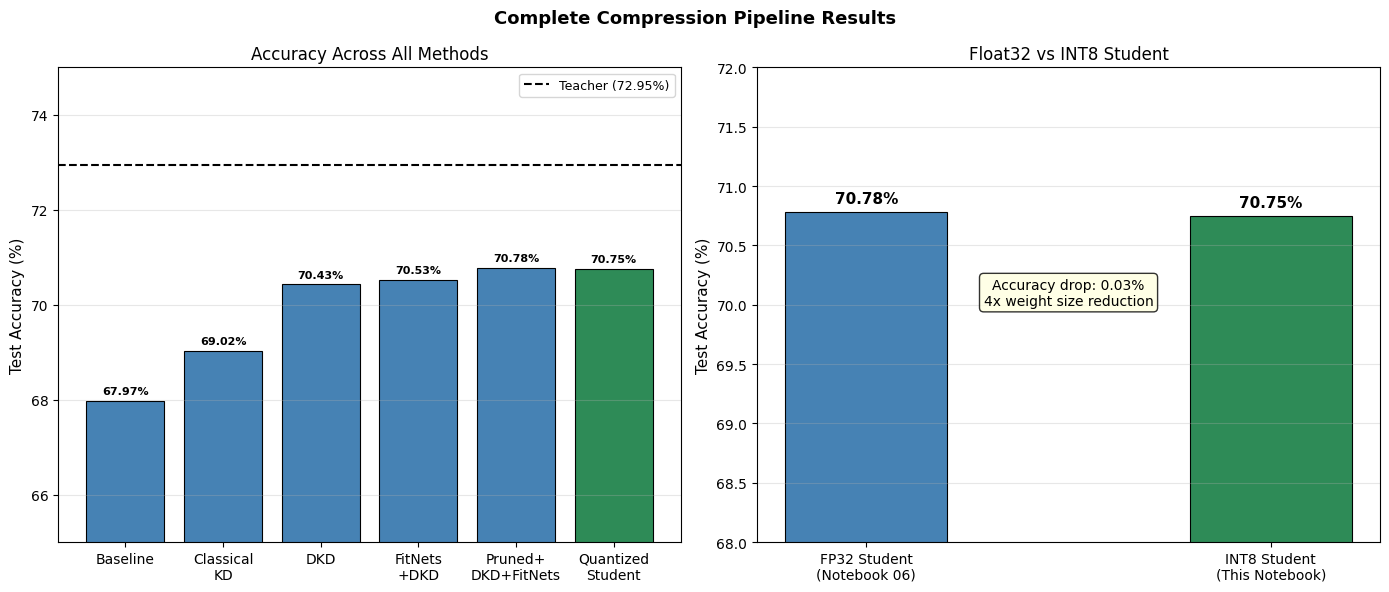

Plot saved to Drive.


In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: Accuracy progression across all methods
methods = ['Baseline', 'Classical\nKD', 'DKD', 'FitNets\n+DKD',
           'Pruned+\nDKD+FitNets', 'Quantized\nStudent']
accs    = [BASELINE_ACC, KD_ACC, DKD_ACC, FITNET_ACC, PRUNED_ACC, acc_after]
colors  = ['steelblue'] * 5 + ['seagreen']

bars = ax1.bar(methods, accs, color=colors, edgecolor='black', linewidth=0.8)
ax1.axhline(y=TEACHER_ACC, color='black', linestyle='--', linewidth=1.5,
            label=f'Teacher ({TEACHER_ACC:.2f}%)')
for bar, acc in zip(bars, accs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{acc:.2f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax1.set_ylabel('Test Accuracy (%)', fontsize=11)
ax1.set_title('Accuracy Across All Methods', fontsize=12)
ax1.legend(fontsize=9); ax1.grid(True, axis='y', alpha=0.3)
ax1.set_ylim([65, 75])

# Right: Accuracy vs deployment readiness
deploy_labels = ['FP32 Student\n(Notebook 06)', 'INT8 Student\n(This Notebook)']
deploy_accs   = [PRUNED_ACC, acc_after]
deploy_colors = ['steelblue', 'seagreen']

bars2 = ax2.bar(deploy_labels, deploy_accs, color=deploy_colors,
                edgecolor='black', linewidth=0.8, width=0.4)
for bar, acc in zip(bars2, deploy_accs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{acc:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax2.set_ylabel('Test Accuracy (%)', fontsize=11)
ax2.set_title('Float32 vs INT8 Student', fontsize=12)
ax2.grid(True, axis='y', alpha=0.3)
ax2.set_ylim([68, 72])

# Add annotation
ax2.annotate(f'Accuracy drop: {acc_before - acc_after:.2f}%\n4x weight size reduction',
             xy=(0.5, 0.5), xycoords='axes fraction',
             ha='center', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle('Complete Compression Pipeline Results', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/final_pipeline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to Drive.')